# Notebook 02: Layer set selection

Compare the planned layer sets at a fixed 384-D descriptor size using SfM validation only.

In [1]:
from dataclasses import replace
from pathlib import Path
import os
import time

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from matplotlib.ticker import PercentFormatter

from cbir.cache import FeatureShardReader
from cbir.config import FusionConfig, config_to_dict, load_project_config, train_fingerprint
from cbir.data.sfm import Sfm30kMetadata
from cbir.evaluation import evaluate_sfm_verified_pairs, final_cls_descriptors_from_cache
from cbir.experiments import matching_experiment, remove_experiment, save_experiment, write_selection
from cbir.fusion import build_descriptor_head
from cbir.plotting import HorizontalReference, SeriesData, plot_series
from cbir.training import HeadTrainer
from cbir.utils import seed_everything

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'pyproject.toml').is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'pyproject.toml').is_file():
    raise RuntimeError('Open this notebook from the project root or notebooks directory.')
os.chdir(PROJECT_ROOT)

CONFIG_PATH = PROJECT_ROOT / 'configs' / 'local.yaml'
cfg = load_project_config(CONFIG_PATH)
CACHE_DIR = cfg.cache.root / 'sfm30k'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / '02_layer_set_selection'
RESULTS_PATH = OUTPUT_DIR / 'results.json'
SELECTION_PATH = PROJECT_ROOT / 'outputs' / 'selections' / 'layer_set_selection.json'
FIXED_OUTPUT_DIM = 384
TRAIN_BATCH_SIZE = cfg.training.batch_size
training_cfg = replace(cfg.training, batch_size=TRAIN_BATCH_SIZE)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

reader = FeatureShardReader(CACHE_DIR, preload=True)
metadata = Sfm30kMetadata.from_official_files(
    cfg.sfm.metadata_path,
    cfg.sfm.names_clusters_path,
)
val_ids = metadata.image_ids('val')
val_cases = metadata.build_validation_cases()

print('Cache:', CACHE_DIR)
print('Fixed descriptor dimension:', FIXED_OUTPUT_DIM)
print('Training batch size:', TRAIN_BATCH_SIZE)

Cache: data/cache/sfm30k
Fixed descriptor dimension: 384
Training batch size: 512


## Experiment definitions

The frozen final CLS baseline has no trainable parameters. Every other entry uses the same train/validation protocol and seed.

In [2]:
LAYER_SETS_ONE_BASED = ((4, 8, 12), (10, 11, 12), (8, 10, 12), (6, 9, 12))


def zero_based(layers):
    return tuple(layer - 1 for layer in layers)


def layer_label(layers):
    return '(' + ', '.join(str(layer) for layer in layers) + ')'


def result_summary(label, fusion_cfg, history, parameter_count):
    if history.best_epoch is None or history.best_checkpoint is None:
        raise RuntimeError('Experiment did not produce a best checkpoint.')
    metrics = history.epochs[history.best_epoch]
    return {
        'configuration': label,
        'head_kind': fusion_cfg.head_kind,
        'layer_weighting': fusion_cfg.gate_mode,
        'layer_indices_one_based': [index + 1 for index in fusion_cfg.layer_indices],
        'descriptor_dimension': fusion_cfg.output_dim,
        'trainable_parameter_count': parameter_count,
        'best_epoch': history.best_epoch + 1,
        'recall_at_1': metrics['val_recall_at_1'],
        'recall_at_5': metrics['val_recall_at_5'],
        'recall_at_10': metrics['val_recall_at_10'],
        'mrr': metrics['val_mrr'],
    }


def run_training_experiment(spec):
    fusion_cfg = FusionConfig(**spec['fusion_config'])
    run_spec = {
        'cache_fingerprint': reader.manifest.fingerprint,
        'fusion_config': config_to_dict(fusion_cfg),
        'training_config': config_to_dict(training_cfg),
        'train_fingerprint': train_fingerprint(
            cache_fingerprint=reader.manifest.fingerprint,
            fusion=fusion_cfg,
            training=training_cfg,
        ),
    }
    previous = matching_experiment(RESULTS_PATH, spec['name'], run_spec)
    if previous is not None:
        return previous['summary']

    remove_experiment(RESULTS_PATH, spec['name'])
    checkpoint_dir = OUTPUT_DIR / 'checkpoints' / spec['name']
    seed_everything(training_cfg.seed)
    head = build_descriptor_head(fusion_cfg)
    parameter_count = sum(parameter.numel() for parameter in head.parameters())
    trainer = HeadTrainer(
        head=head,
        reader=reader,
        train_pairs=metadata.train_pairs,
        fusion_config=fusion_cfg,
        training_config=training_cfg,
        validation_cases=val_cases,
        validation_image_ids=val_ids,
        output_dir=checkpoint_dir,
    )
    history = trainer.fit()
    summary = result_summary(spec['label'], fusion_cfg, history, parameter_count)
    save_experiment(
        RESULTS_PATH,
        name=spec['name'],
        run_spec=run_spec,
        summary=summary,
        history=history.epochs,
        checkpoint=history.best_checkpoint,
    )
    return summary


def frozen_baseline():
    run_spec = {'cache_fingerprint': reader.manifest.fingerprint, 'kind': 'frozen_final_cls'}
    previous = matching_experiment(RESULTS_PATH, 'final_cls_384_frozen', run_spec)
    if previous is not None:
        return previous['summary']
    report = evaluate_sfm_verified_pairs(
        final_cls_descriptors_from_cache(reader, val_ids),
        val_ids,
        val_cases,
        query_block_size=cfg.evaluation.query_block_size,
    )
    summary = {
        'configuration': 'Final CLS — 384-D (frozen)',
        'head_kind': 'frozen_final_cls',
        'layer_weighting': None,
        'layer_indices_one_based': [12],
        'descriptor_dimension': 384,
        'trainable_parameter_count': 0,
        'best_epoch': None,
        'recall_at_1': report.recall_at_1,
        'recall_at_5': report.recall_at_5,
        'recall_at_10': report.recall_at_10,
        'mrr': report.mrr,
    }
    save_experiment(
        RESULTS_PATH, name='final_cls_384_frozen', run_spec=run_spec,
        summary=summary, history=[], checkpoint=None,
    )
    return summary


EXPERIMENT_SPECS = []

for layers in LAYER_SETS_ONE_BASED:
    indices = zero_based(layers)
    suffix = '_'.join(str(layer) for layer in layers)
    EXPERIMENT_SPECS.append({
        'name': f'cls_concat_{suffix}',
        'label': f'CLS concatenation {layer_label(layers)}',
        'fusion_config': config_to_dict(replace(
            cfg.fusion, layer_indices=indices, output_dim=FIXED_OUTPUT_DIM,
            head_kind='cls_concat', gate_mode=None,
        )),
    })
    for mode, title in (
        ('uniform', 'Uniform layer weighting'),
        ('static', 'Static layer weighting'),
        ('dynamic', 'Dynamic layer weighting'),
    ):
        EXPERIMENT_SPECS.append({
            'name': f'{mode}_layer_weighting_{suffix}',
            'label': f'{title} {layer_label(layers)}',
            'fusion_config': config_to_dict(replace(
                cfg.fusion, layer_indices=indices, output_dim=FIXED_OUTPUT_DIM,
                head_kind='global_local', gate_mode=mode,
            )),
        })

## Run and compare

In [3]:
experiment_results = {'final_cls_384_frozen': frozen_baseline()}
for spec in EXPERIMENT_SPECS:
    started_at = time.perf_counter()
    experiment_results[spec['name']] = run_training_experiment(spec)
    elapsed_seconds = time.perf_counter() - started_at
    print(f"Finished {spec['label']} in {elapsed_seconds:.1f} seconds.")

result_table = pd.DataFrame(experiment_results.values())
result_table = result_table.sort_values(['recall_at_1', 'mrr'], ascending=False).reset_index(drop=True)
display(result_table[[
    'configuration', 'descriptor_dimension', 'trainable_parameter_count',
    'best_epoch', 'recall_at_1', 'recall_at_5', 'recall_at_10', 'mrr',
]])

Finished CLS concatenation (4, 8, 12) in 0.0 seconds.
Finished Uniform layer weighting (4, 8, 12) in 0.0 seconds.
Finished Static layer weighting (4, 8, 12) in 0.0 seconds.
Finished Dynamic layer weighting (4, 8, 12) in 0.0 seconds.
Finished CLS concatenation (10, 11, 12) in 0.0 seconds.
Finished Uniform layer weighting (10, 11, 12) in 0.0 seconds.
Finished Static layer weighting (10, 11, 12) in 0.0 seconds.
Finished Dynamic layer weighting (10, 11, 12) in 0.0 seconds.
Finished CLS concatenation (8, 10, 12) in 0.0 seconds.
Finished Uniform layer weighting (8, 10, 12) in 0.0 seconds.
Finished Static layer weighting (8, 10, 12) in 0.0 seconds.
Finished Dynamic layer weighting (8, 10, 12) in 0.0 seconds.
Finished CLS concatenation (6, 9, 12) in 0.0 seconds.
Finished Uniform layer weighting (6, 9, 12) in 0.0 seconds.
Finished Static layer weighting (6, 9, 12) in 0.0 seconds.
Finished Dynamic layer weighting (6, 9, 12) in 0.0 seconds.


,configuration,descriptor_dimension,trainable_parameter_count,best_epoch,recall_at_1,recall_at_5,recall_at_10,mrr
0,"Dynamic layer weighting (8, 10, 12)",384,890500,20.0,0.928445,0.953282,0.963927,0.940020
1,"Static layer weighting (8, 10, 12)",384,890500,15.0,0.928445,0.949734,0.963927,0.939702
2,"Uniform layer weighting (8, 10, 12)",384,890500,15.0,0.928445,0.949734,0.963927,0.939661
3,"CLS concatenation (6, 9, 12)",384,445056,27.0,0.926671,0.953282,0.965701,0.938894
4,"Static layer weighting (4, 8, 12)",384,890500,20.0,0.926671,0.950917,0.963927,0.938427
5,"Uniform layer weighting (4, 8, 12)",384,890500,20.0,0.926671,0.950917,0.963927,0.938424
6,"CLS concatenation (8, 10, 12)",384,445056,22.0,0.926079,0.953282,0.966884,0.938958
7,"Dynamic layer weighting (4, 8, 12)",384,890500,22.0,0.926079,0.950917,0.963927,0.938129
8,"Uniform layer weighting (6, 9, 12)",384,890500,17.0,0.924305,0.952691,0.966292,0.937745
9,"Static layer weighting (6, 9, 12)",384,890500,17.0,0.924305,0.952691,0.966292,0.937743


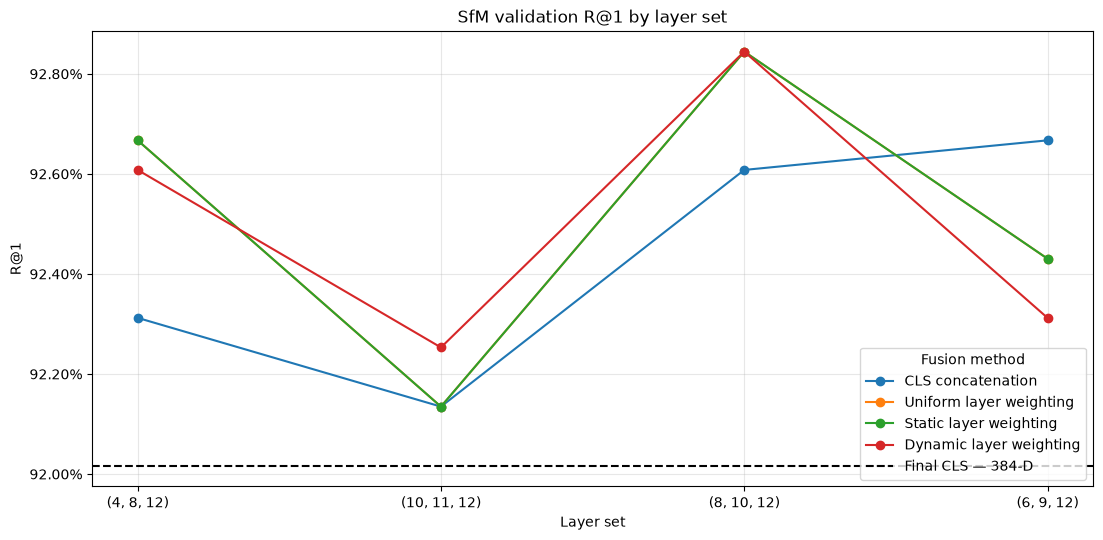

In [4]:
series = {}
for prefix, label in (
    ('cls_concat', 'CLS concatenation'),
    ('uniform_layer_weighting', 'Uniform layer weighting'),
    ('static_layer_weighting', 'Static layer weighting'),
    ('dynamic_layer_weighting', 'Dynamic layer weighting'),
):
    values = []
    for layers in LAYER_SETS_ONE_BASED:
        name = f'{prefix}_{"_".join(str(layer) for layer in layers)}'
        values.append(experiment_results[name]['recall_at_1'])
    series[label] = SeriesData(x=list(range(len(LAYER_SETS_ONE_BASED))), y=values)

figure, axis = plot_series(
    series,
    title='SfM validation R@1 by layer set',
    xlabel='Layer set',
    ylabel='R@1',
    legend_title='Fusion method',
    horizontal_references={
        'Final CLS — 384-D': HorizontalReference(
            experiment_results['final_cls_384_frozen']['recall_at_1']
        )
    },
    fig_size=(11, 5.5),
    save_path=OUTPUT_DIR / 'figures' / 'layer_set_r1.png',
)
axis.set_xticks(range(len(LAYER_SETS_ONE_BASED)), [layer_label(item) for item in LAYER_SETS_ONE_BASED])
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
display(figure)
plt.close(figure)

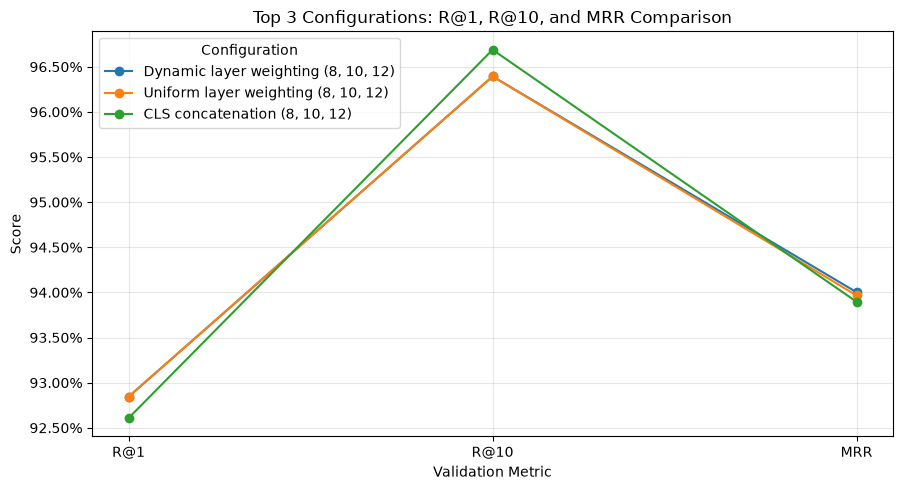

In [5]:
# Compare R@1, R@10, and MRR for the top 3 configurations
metric_keys = ('recall_at_1', 'recall_at_10', 'mrr')
metric_labels = ['R@1', 'R@10', 'MRR']

top3_keys = [
    'dynamic_layer_weighting_8_10_12',
    'uniform_layer_weighting_8_10_12',
    'cls_concat_8_10_12',
]

top3_series = {
    experiment_results[key]['configuration']: SeriesData(
        x=list(range(len(metric_keys))),
        y=[experiment_results[key][metric] for metric in metric_keys],
    )
    for key in top3_keys
    if key in experiment_results
}

top3_figure, top3_axis = plot_series(
    top3_series,
    title='Top 3 Configurations: R@1, R@10, and MRR Comparison',
    xlabel='Validation Metric',
    ylabel='Score',
    legend_title='Configuration',
    fig_size=(9, 5),
    save_path=OUTPUT_DIR / 'figures' / 'top3_layer8_10_12_metrics.png',
)

top3_axis.set_xticks(range(len(metric_keys)), metric_labels)
top3_axis.yaxis.set_major_formatter(PercentFormatter(1.0))
display(top3_figure)
plt.close(top3_figure)


## Record the winner configuration

In [7]:
SELECTED_EXPERIMENT = 'dynamic_layer_weighting_8_10_12'

if SELECTED_EXPERIMENT not in experiment_results:
    raise KeyError(f'Unknown completed experiment: {SELECTED_EXPERIMENT}')
selected_spec = next(spec for spec in EXPERIMENT_SPECS if spec['name'] == SELECTED_EXPERIMENT)
selected = experiment_results[SELECTED_EXPERIMENT]
write_selection(SELECTION_PATH, {
    'selected_on': 'Manual student decision after SfM-30k validation inspection only',
    'experiment_name': SELECTED_EXPERIMENT,
    'experiment_label': selected['configuration'],
    'cache_fingerprint': reader.manifest.fingerprint,
    'fusion_config': selected_spec['fusion_config'],
    'training_config': config_to_dict(training_cfg),
    'selected_epoch_count': selected['best_epoch'],
    'source_experiment': f'02_layer_set_selection/{SELECTED_EXPERIMENT}',
})
print('Saved layer-set selection to', SELECTION_PATH)

Saved layer-set selection to /home/armin/courses/ImageProcessing_FinalProject/outputs/selections/layer_set_selection.json
